In [1]:
using Random
using Flux

In [4]:

function holdOut(N::Int, P::Real)
    @assert 0 <= P <= 1 "P debe estar entre 0 y 1"
    indices = randperm(N)  # Generate a random permutation of indexes
    split_point = floor(Int, N * (1 - P))  # Determines cut-off point
    return (indices[1:split_point], indices[split_point+1:end])  # Returns the tuple with the subdatasets
end

holdOut (generic function with 2 methods)

In [6]:
sets = holdOut(150, 0.3)
typeof(sets)


Tuple{Vector{Int64}, Vector{Int64}}

In [5]:

function holdOut(N::Int, Pval::Real, Ptest::Real)
    @assert 0 <= Pval + Ptest <= 1 "La suma de Pval y Ptest debe estar entre 0 y 1"
    (train_test, test) = holdOut(N, Ptest)  # Separates the test dataset
    Pval_adjusted = Pval / (1 - Ptest)  # Adjusts Pval for the remaining datasets 
    train, val = holdOut(length(train_test), Pval_adjusted)  # Separates validate dataset from training dataset
    return (train_test[train], train_test[val], test)  # Returns the three datasets
end

holdOut (generic function with 2 methods)

In [12]:
(a, b, c) = holdOut(150, 0.15, 0.15)
x = length(a) + length(b) + length(c)
typeof((a, b, c))


Tuple{Vector{Int64}, Vector{Int64}, Vector{Int64}}

In [89]:
function trainClassANN(topology::AbstractArray{<:Int,1},
    trainingDataset:: Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}};
    validationDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}=
   (Array{eltype(trainingDataset[1]),2}(undef,0,size(trainingDataset[1],2)),
   falses(0,size(trainingDataset[2],2))),
    testDataset:: Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}=
   (Array{eltype(trainingDataset[1]),2}(undef,0,size(trainingDataset[1],2)),
   falses(0,size(trainingDataset[2],2))),
    transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology)),
    maxEpochs::Int=1000, minLoss::Real=0.0, learningRate::Real=0.01,
    maxEpochsVal::Int=20)

    println("hola")

    trainingInputs = Float32.(trainingDataset[1]') # Convertir inputs a float32
    validationInputs = Float32.(validationDataset[1]') # Convertir inputs a float32
    testInputs = Float32.(testDataset[1]') # Convertir inputs a float32

    trainingTargets = trainingDataset[2]' # Extraer labels
    validationTargets = validationDataset[2]' # Extraer labels
    testTargets = testDataset[2]' # Extraer labels
    
    numTrainingInputs = size(trainingInputs, 1)
    numTrainingOutputs = size(trainingTargets, 1)
    
    ann = buildClassANN(numTrainingInputs, topology, numTrainingOutputs; transferFunctions) # build ANN
    loss(model, x,y) = (size(y,1) == 1) ? Losses.binarycrossentropy(model(x),y) : Losses.crossentropy(model(x),y) # loss function
    
    opt_state = Flux.setup(Adam(learningRate), ann) 

    trainingLosses = Float32[] # losses array
    validationLosses = Float32[] # validation losses
    testLosses = Float32[] # test losses array

    push!(trainingLosses, loss(ann, trainingInputs, trainingTargets)) # append epoch 0 loss 

    if !isempty(validationInputs)
        push!(validationLosses, loss(ann, validationInputs, validationTargets))
    end
    if !isempty(testInputs)
        push!(testLosses, loss(ann, testInputs, testTargets))
    end

    bestValidationLoss = Inf
    bestAnn = deepcopy(ann)
    epochsWithoutImprovement = 0
    epochs = 0
    
    for epoch in 1:maxEpochs
      
        Flux.train!(loss, ann, [(trainingInputs, trainingTargets)], opt_state)
        epochs = epochs + 1
        currentTrainingLoss = loss(ann, trainingInputs, trainingTargets)
        push!(trainingLosses, currentTrainingLoss)
        
        if currentTrainingLoss <= minLoss
            break
        end
    
        # VALIDACIÓN (si hay conjunto de validación)
        if !isempty(validationInputs)
            currentValidationLoss = loss(ann, validationInputs, validationTargets)
            push!(validationLosses, currentValidationLoss)
            
            # PARADA TEMPRANA: Si el loss en validación mejora, actualizar mejor modelo
            if currentValidationLoss < bestValidationLoss
       
                bestValidationLoss = currentValidationLoss
                bestAnn = deepcopy(ann)
                epochsWithoutImprovement = 0  # Reiniciar el contador de epochs sin mejora
            else
                epochsWithoutImprovement += 1
            end
            
        end
    
        # PRUEBA (si hay conjunto de test)
        if !isempty(testInputs)
            currentTestLoss = loss(ann, testInputs, testTargets)
            push!(testLosses, currentTestLoss)
        end
    
        # CRITERIO DE PARADA TEMPRANA
        if epochsWithoutImprovement >= maxEpochsVal
            println("Parada temprana en epoch $epoch ")
            break
        end

    end

    println("Epochs completados: $epochs")
    println("Tamaño trainingLosses: $(length(trainingLosses))")
    println("Tamaño validationLosses: $(length(validationLosses))")
    println("Tamaño testLosses: $(length(testLosses))")
    
    if !isempty(validationInputs)
        return (bestAnn, trainingLosses, validationLosses, testLosses)
    else
        return (ann, trainingLosses, validationLosses, testLosses)
    end
end;
   

trainClassANN (generic function with 2 methods)

In [8]:
function trainClassANN(topology::AbstractArray{<:Int,1},
    trainingDataset:: Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}};
    validationDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}}=
   (Array{eltype(trainingDataset[1]),2}(undef,0,size(trainingDataset[1],2)),
   falses(0)),
    testDataset:: Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}}=
   (Array{eltype(trainingDataset[1]),2}(undef,0,size(trainingDataset[1],2)),
   falses(0)),
    transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology)),
    maxEpochs::Int=1000, minLoss::Real=0.0, learningRate::Real=0.01,
    maxEpochsVal::Int=20) 

    newTrainingDataset = (trainingDataset[1], reshape(trainingDataset[2], :, 1))
    newValidationDataset = (validationDataset[1], reshape(validationDataset[2], :, 1))
    newTestDataset = (testDataset[1], reshape(testDataset[2], :, 1))

    return trainClassANN(topology, newTrainingDataset; validationDataset=newValidationDataset, testDataset=newTestDataset, 
                         transferFunctions=transferFunctions, maxEpochs=maxEpochs, minLoss=minLoss, 
                         learningRate=learningRate, maxEpochsVal=maxEpochsVal)
end

trainClassANN (generic function with 2 methods)

# Testing pipeline

In [197]:
# Cargamos el dataset
using DelimitedFiles: readdlm
include("/Users/rafa/Documents/Uni/Cuatri4/machine_learning/FAA_practices/src/boletin_1/45159263M_49918198X_48118738R_54153358L.jl")

dataset = readdlm(ruta_rafa,',')

# Preparamos las entradas
inputs = Float32.(dataset[:,1:4])
targets = oneHotEncoding(dataset[:,5])

150×3 Matrix{Bool}:
 1  0  0
 1  0  0
 1  0  0
 1  0  0
 1  0  0
 1  0  0
 1  0  0
 1  0  0
 1  0  0
 1  0  0
 ⋮     
 0  0  1
 0  0  1
 0  0  1
 0  0  1
 0  0  1
 0  0  1
 0  0  1
 0  0  1
 0  0  1

In [198]:
inputs = normalizeZeroMean!(inputs)

150×4 Matrix{Float32}:
 -0.897675    1.02861   -1.33679   -1.30859
 -1.1392     -0.12454   -1.33679   -1.30859
 -1.38073     0.336721  -1.39347   -1.30859
 -1.50149     0.10609   -1.28012   -1.30859
 -1.01844     1.25924   -1.33679   -1.30859
 -0.535385    1.95113   -1.16677   -1.04652
 -1.50149     0.797981  -1.33679   -1.17756
 -1.01844     0.797981  -1.28012   -1.30859
 -1.74302    -0.35517   -1.33679   -1.30859
 -1.1392      0.10609   -1.28012   -1.43963
  ⋮                                
  1.27606     0.10609    0.760212   1.44312
 -0.0523316  -0.816431   0.760212   0.918985
  1.1553      0.336721   1.21362    1.44312
  1.03454     0.567351   1.10027    1.70519
  1.03454    -0.12454    0.816887   1.44312
  0.551485   -1.27769    0.703536   0.918985
  0.793011   -0.12454    0.816887   1.05002
  0.430721    0.797981   0.930239   1.44312
  0.0684316  -0.12454    0.760212   0.787951

In [273]:
train, test, val = holdOut(150, 0.15, 0.15)

([32, 6, 108, 146, 100, 12, 126, 78, 130, 86  …  38, 102, 25, 139, 26, 91, 128, 66, 97, 89], [107, 101, 83, 141, 27, 98, 61, 31, 82, 105  …  115, 50, 77, 63, 36, 39, 144, 57, 76, 4], [24, 8, 103, 106, 28, 33, 140, 114, 64, 136  …  69, 117, 125, 113, 81, 104, 118, 17, 34, 55])

In [274]:
trainInputs = inputs[train, :]
valInputs = inputs[val, :]
testInputs = inputs[test, :]

trainLabels = targets[train, :]
valLabels = targets[val, :]
testLabels = targets[test, :]

size(train, 1)

104

In [275]:
size(val, 1)

23

In [276]:
patience = 10

insights = trainClassANN(
    [8, 6], 
    (trainInputs, trainLabels),
    validationDataset=(valInputs, valLabels),
    testDataset=(testInputs, testLabels),
    transferFunctions=[σ, σ], 
    maxEpochs=100, 
    minLoss=0.0, 
    learningRate=0.1, 
    maxEpochsVal=patience
)

hola
Parada temprana en epoch 64 
Epochs completados: 64
Tamaño trainingLosses: 65
Tamaño validationLosses: 65
Tamaño testLosses: 65


(Chain(Dense(4 => 8, σ), Dense(8 => 6, σ), Dense(6 => 3), softmax), Float32[1.1752715, 1.0880129, 1.0807974, 1.0013683, 0.919619, 0.8622468, 0.8102756, 0.74786896, 0.6805602, 0.61987484  …  0.07065619, 0.06874007, 0.06740859, 0.066569954, 0.06592779, 0.06519515, 0.06427206, 0.06322318, 0.06217136, 0.061221354], Float32[1.292026, 1.1067322, 1.0273161, 0.9399808, 0.87377214, 0.83458877, 0.79626566, 0.74463695, 0.6875145, 0.6355909  …  0.01620884, 0.017594414, 0.019708004, 0.022105845, 0.02422579, 0.025517412, 0.02551418, 0.024089236, 0.02168576, 0.019051382], Float32[1.1473889, 1.0868988, 1.096767, 1.0184319, 0.9309934, 0.86650866, 0.8088123, 0.7428445, 0.6741748, 0.61415887  …  0.018089203, 0.014550163, 0.012288696, 0.010895051, 0.010037413, 0.009537664, 0.009337437, 0.009455195, 0.0099441735, 0.010834956])

In [252]:
size(insights[3])

(76,)

In [253]:
println(insights[3])



Float32[1.2235155, 1.0912346, 1.1229541, 1.1310475, 1.0803478, 0.99753755, 0.9069212, 0.82414645, 0.7575974, 0.70894647, 0.6739489, 0.64560586, 0.6193226, 0.5950137, 0.575713, 0.5637002, 0.55704576, 0.5522087, 0.5488998, 0.548618, 0.55072516, 0.5519333, 0.5498346, 0.54522306, 0.5406404, 0.5377547, 0.53631926, 0.5354805, 0.53521746, 0.53588194, 0.5369658, 0.5370518, 0.53508216, 0.53127164, 0.5266411, 0.5219196, 0.5170496, 0.51160187, 0.50524163, 0.49752447, 0.48751715, 0.47418544, 0.45749164, 0.43892583, 0.4206013, 0.40396306, 0.389568, 0.37745696, 0.3671821, 0.35779637, 0.34794965, 0.3358934, 0.31977543, 0.2983166, 0.27124333, 0.23925659, 0.2046458, 0.17291026, 0.15162122, 0.14398038, 0.14442217, 0.14331883, 0.13615403, 0.12604725, 0.11821548, 0.11549643, 0.116804935, 0.118612796, 0.11848607, 0.11748857, 0.11886547, 0.12490376, 0.13486972, 0.1449767, 0.15152746, 0.15581276]


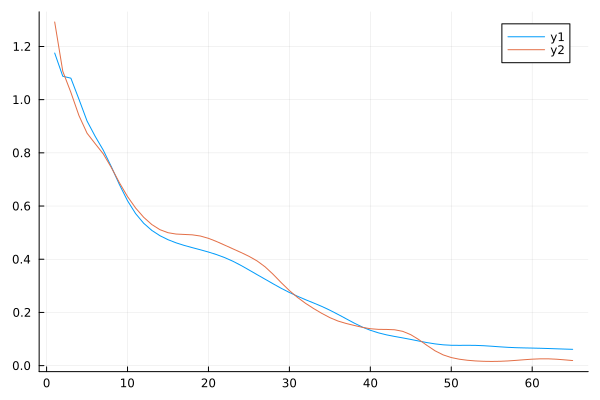

In [277]:
using Plots

p = plot(1:size(insights[2], 1), insights[2])
plot!(p, 1:size(insights[3], 1), insights[3])

In [278]:
try_ann = insights[1]
loss(model, x,y) = (size(y,1) == 1) ? Losses.binarycrossentropy(model(x),y) : Losses.crossentropy(model(x),y) # loss function
currentValidationLoss = loss(try_ann, valInputs', valLabels')

0.015735328f0

In [279]:
currentValidationLoss == insights[3][size(insights[3], 1) - patience]

true

In [280]:
output_data = try_ann(testInputs')


3×23 Matrix{Float32}:
 0.00125776  1.66474f-5  0.00870558  …  0.00827913  0.00694331  0.990613
 0.269915    0.00377924  0.988001       0.981025    0.988293    0.00935984
 0.728827    0.996204    0.00329384     0.0106962   0.00476376  2.7165f-5

In [282]:
accuracy(output_data', testLabels)

1.0